In [6]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

Exercise 4-1.
Write a Python function that takes two vectors as input and provides two numbers as
output: the Pearson correlation coefficient and the cosine similarity value. Write code
that follows the formulas presented in this chapter; don’t simply call np.corrcoef and
spatial.distance.cosine. Check that the two output values are identical when the
variables are already mean centered and different when the variables are not mean
centered.

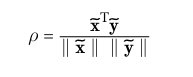 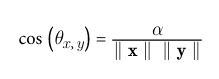 <br>
alpha = np.dot(vector_1,vector_2)

In [7]:
def corrAndCosine(vector_1,vector_2):

    correlation = (np.dot(vector_1.T,vector_2))/(np.linalg.norm(vector_1) * np.linalg.norm(vector_2))


    vector_1 = vector_1 - np.mean(vector_1)
    vector_2 = vector_2 - np.mean(vector_2)

    cosineSimilarity = np.dot(vector_1,vector_2) / (np.linalg.norm(vector_1) * np.linalg.norm(vector_2))
    
    return correlation , cosineSimilarity

In [8]:
v1 = np.random.randn(15) 
v2 = np.random.randn(15)

In [9]:
# Variables passed were not mean centred
corrAndCosine(v1,v2)

(np.float64(0.4150569153171134), np.float64(0.48363578646426025))

In [10]:
v1 = np.random.randn(15) + 30
v2 = np.random.randn(15)

In [11]:
# Variables passed with mean centered
mean_centered_vector1 = (v1 - np.mean(v1))
mean_centered_vector2 = (v2 - np.mean(v2))

In [12]:
corrAndCosine(mean_centered_vector1,mean_centered_vector2)

(np.float64(-0.26962591751059406), np.float64(-0.26962591751059406))

In [13]:
# As you can clearly see the first observation we get two different values for correlation matrix equation  and cosine similarity . 
# Why we deliberately passed the vectors without mean centring values .
# In second case we pass the vectors mean centred and as you can see the values found are exactly the same .
# Why ?  Because the values passed now are mean centred which is the assumption of the first formula for correlation .

Let’s continue exploring the difference between correlation and cosine similarity.
Create a variable containing the integers 0 through 3, and a second variable equaling
the first variable plus some offset. You will then create a simulation in which you
systematically vary that offset between −50 and +50 (that is, the first iteration of the
simulation will have the second variable equal to [−50, −49, −48, −47]). In a for
loop, compute the correlation and cosine similarity between the two variables and
store these results. Then make a line plot showing how the correlation and cosine
similarity are affected by the mean offset. You should be able to reproduce Figure 4-4.

In [14]:
offset = np.arange(-50,50)
variable_1 = np.arange(0,4,dtype='float')
result = np.zeros((len(offset),2))

In [15]:
for i in range(len(offset)):
    result[i,:] = corrAndCosine(variable_1 , variable_1 + offset[i])

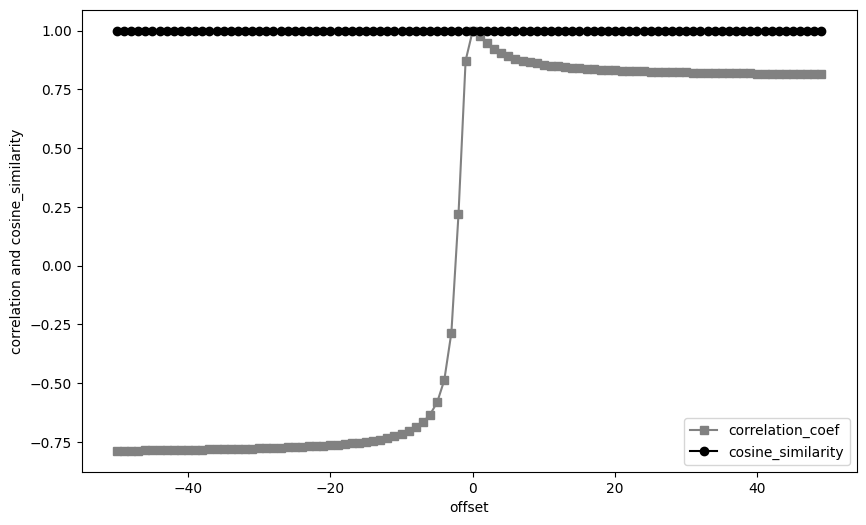

In [16]:
plt.figure(figsize=(10,6))
plt.plot(offset,result[:,0],label='correlation_coef',color="#818181",marker='s')
plt.plot(offset,result[:,1],label='cosine_similarity',color="#000000",marker='o')
plt.xlabel('offset')
plt.ylabel('correlation and cosine_similarity')
plt.legend()
plt.show()

There are several Python functions to compute the Pearson correlation coefficient.
One of them is called pearsonr and is located in the stats module of the SciPy
library. Open the source code for this file (hint: ??functionname) and make sure you
understand how the Python implementation maps onto the formulas introduced in
this chapter

In [17]:
# import the function
from scipy.stats import pearsonr

# inspect the source code
pearsonr(v1,v2)

PearsonRResult(statistic=np.float64(-0.269625917510594), pvalue=np.float64(0.3311385145131152))

Your goal in this exercise is to determine whether your own bare-bones correla
tion function is faster than NumPy’s corrcoef function. Modify the function from
Exercise 4-2 to compute only the correlation coefficient. Then, in a for loop over
1,000 iterations, generate two variables of 500 random numbers and compute the
correlation between them. Time the for loop. Then repeat but using np.corrcoef.
In my tests, the custom function was about 33% faster than np.corrcoef. In these
toy examples, the differences are measured in milliseconds, but if you are running
billions of correlations with large datasets, those milliseconds really add up! (Note
that writing your own functions without input checks has the risk of input errors that
would be caught by np.corrcoef.) (Also note that the speed advantage breaks down
for larger vectors. Try it!)

In [18]:
import time

In [19]:
def corrOnly(v1,v2):
    v1 = v1 - np.mean(v1)
    v2 = v2 - np.mean(v2)
    correlation = np.dot(v1.T,v2)/(np.linalg.norm(v1) * np.linalg.norm(v2))

In [20]:
epochs = 1000

In [21]:
time_start = time.time()
for i in range(epochs):
    variable1 = np.random.randn(500,2)
    corrOnly(variable1[:,0],variable1[:,1])
custom_loop_time = time.time() - time_start

In [22]:
custom_loop_time

0.5065977573394775

In [23]:
time_start = time.time()
for i in range(epochs):
    variable1 = np.random.randn(500,2)
    pearsonr(variable1[:,0],variable1[:,1])
function_loop_time = time.time() - time_start

In [24]:
function_loop_time

1.367018461227417

In [ ]:
# The diffirence : 
(function_loop_time / custom_loop_time )

2.6984297530384853

In [29]:
# The function difference between

Next, write a for loop over the time points in the signal. At each time point, compute
the dot product between the kernel and a segment of the time series data that has
the same length as the kernel. You should produce a plot that looks like graph C in
Figure 4-5. (Focus more on the result than on the aesthetics.) Notice that our edge
detector returned 0 when the signal was flat, +1 when the signal jumped up, and −1
when the signal jumped down.
Feel free to continue exploring this code. For example, does anything change if you
pad the kernel with zeros ([0 −1 1 0])? What about if you flip the kernel to be [1 −1]?
How about if the kernel is asymmetric ([−1 2])?

In [48]:
kernel_vector = np.array([-1,1])
signal = np.zeros(30)
signal[10:20] = 1

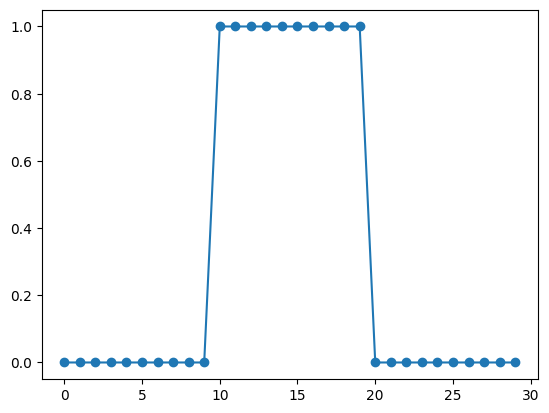

In [49]:
plt.plot(signal,marker='o')
plt.show()

In [50]:
featuremap = np.zeros(len(signal)) # The product which will give us the edge of the signal using the kernel

In [51]:
for i in range(1,len(signal)-1):
    featuremap[i] = np.dot(kernel_vector,signal[i-1:i+1])

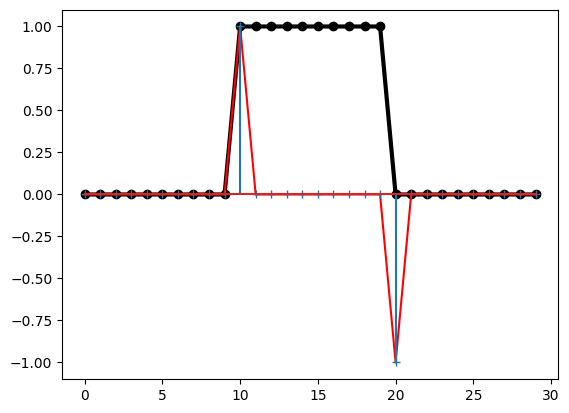

In [73]:
plt.plot(signal,marker='o',color="#000000",linewidth=3)
plt.plot(featuremap,color="#FF0000")
plt.stem(range(len(featuremap)),featuremap,markerfmt='+',linefmt='')
plt.show()